# Task 1: Term Deposit Subscription Prediction (Bank Marketing)
### DevelopersHub Corporation — Data Science & Analytics Advanced Internship Tasks

---

## 1. Problem Statement
Marketing campaigns are costly and resource-intensive. Blanket targeting of all bank customers often leads to low conversion rates, wasted operational costs, and customer fatigue. A retail bank wants to optimize its telemarketing campaigns by identifying customers who are most likely to subscribe to a term deposit.

## 2. Objective
Build and compare classification models to predict whether a customer will subscribe to a term deposit (`deposit` = 'yes' or 'no'). Interpret the predictions using Explainable AI (LIME) to understand key risk/conversion drivers, perform customer behavior analysis, and propose data-driven marketing strategies.

## 3. Dataset Description
The dataset contains information about bank customers, their personal details, and records of past contacts.
Key features include:
- `age`: Customer's age (numeric)
- `job`: Type of job (categorical)
- `marital`: Marital status (categorical)
- `education`: Level of education (categorical)
- `default`: Has credit in default? (categorical: 'no', 'yes')
- `balance`: Average yearly balance, in euros (numeric)
- `housing`: Has housing loan? (categorical: 'no', 'yes')
- `loan`: Has personal loan? (categorical: 'no', 'yes')
- `contact`: Contact communication type (categorical)
- `day`: Last contact day of the month (numeric)
- `month`: Last contact month of year (categorical)
- `duration`: Last contact duration, in seconds (numeric)
- `campaign`: Number of contacts performed during this campaign for this client (numeric)
- `pdays`: Number of days that passed by after the client was last contacted from a previous campaign (numeric, -1 means client was not previously contacted)
- `previous`: Number of contacts performed before this campaign for this client (numeric)
- `poutcome`: Outcome of the previous marketing campaign (categorical)
- **Target Variable**: `deposit` — has the client subscribed to a term deposit? (binary: 'yes', 'no')

## 4. Import Required Libraries
We will import standard libraries for data analysis, visualization, machine learning preprocessing, classification modeling, evaluation, and Explainable AI (LIME).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Machine Learning Preprocessing and Modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

# Explainable AI (XAI)
import lime
import lime.lime_tabular

print("Libraries imported successfully!")

Libraries imported successfully!


## 5. Dataset Loading
We will load the bank marketing dataset `bank.csv` from the data folder.

In [2]:
# Load the dataset
data_path = "../data/bank.csv"
if not os.path.exists(data_path):
    # Fallback path
    data_path = "/Users/yasirkhan/Desktop/develpoer hub phase. two /task_1_bank_marketing/data/bank.csv"

df = pd.read_csv(data_path)
print(f"Dataset loaded successfully. Shape: {df.shape}")

Dataset loaded successfully. Shape: (11162, 17)


## 6. Initial Data Inspection
We will inspect the first rows, columns, data types, summary statistics, check for missing values, and check for duplicate records.

In [3]:
# First 5 rows
print("--- First 5 Rows ---")
display(df.head())

# Column names & Data types
print("\n--- Column Information & Data Types ---")
df.info()

# Summary statistics for numerical features
print("\n--- Numerical Summary Statistics ---")
display(df.describe())

# Summary statistics for categorical features
print("\n--- Categorical Summary Statistics ---")
display(df.describe(include=['object']))

# Missing values check
print("\n--- Missing Values Count ---")
print(df.isnull().sum())

# Duplicate records check
print("\n--- Duplicate Records ---")
print(f"Number of duplicate records: {df.duplicated().sum()}")

--- First 5 Rows ---


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes



--- Column Information & Data Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB

--- Numerical Summary Statistics ---


,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000



--- Categorical Summary Statistics ---


,job,marital,education,default,housing,loan,contact,month,poutcome,deposit
count,11162,11162,11162,11162,11162,11162,11162,11162,11162,11162
unique,12,3,4,2,2,2,3,12,4,2
top,management,married,secondary,no,no,no,cellular,may,unknown,no
freq,2566,6351,5476,10994,5881,9702,8042,2824,8326,5873



--- Missing Values Count ---
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

--- Duplicate Records ---
Number of duplicate records: 0


## 7. Target Variable Distribution
We will analyze the distribution of our target variable `deposit` to understand class balance.

Target Counts:
deposit
no     5873
yes    5289
Name: count, dtype: int64

Target Percentages:
deposit
no     52.616019
yes    47.383981
Name: proportion, dtype: float64


/var/folders/22/fvr61vqx19l3ktt6mmyck72m0000gn/T/ipykernel_59213/3579071720.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='deposit', palette='viridis')


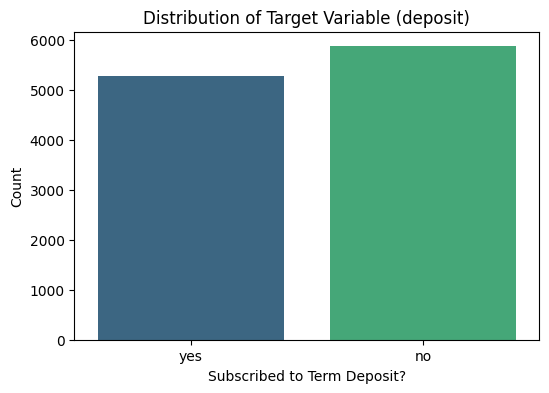

In [4]:
# Target variable distribution
counts = df['deposit'].value_counts()
percentages = df['deposit'].value_counts(normalize=True) * 100

print("Target Counts:")
print(counts)
print("\nTarget Percentages:")
print(percentages)

# Visualize target distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='deposit', palette='viridis')
plt.title('Distribution of Target Variable (deposit)')
plt.xlabel('Subscribed to Term Deposit?')
plt.ylabel('Count')
plt.show()

## 8. Identify Numerical and Categorical Features
We separate features into numerical and categorical features for custom pre-processing.

In [5]:
# Separate features
cat_features = df.select_dtypes(include=['object', 'category']).columns.tolist()
cat_features.remove('deposit')
num_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Numerical Features ({len(num_features)}): {num_features}")
print(f"Categorical Features ({len(cat_features)}): {cat_features}")

Numerical Features (7): ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Categorical Features (9): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


## 9. Data Cleaning & Handling Missing Values
We verified that there are no standard null values. Now we will inspect if there are 'unknown' values in our categorical features (which act as missing information in the UCI Bank dataset).

In [6]:
# Check for 'unknown' placeholders
print("Count of 'unknown' values per categorical feature:")
for col in cat_features:
    unknown_count = (df[col] == 'unknown').sum()
    print(f"  {col}: {unknown_count} ({(unknown_count / len(df) * 100):.2f}% of data)")

Count of 'unknown' values per categorical feature:
  job: 70 (0.63% of data)
  marital: 0 (0.00% of data)
  education: 497 (4.45% of data)
  default: 0 (0.00% of data)
  housing: 0 (0.00% of data)
  loan: 0 (0.00% of data)
  contact: 2346 (21.02% of data)
  month: 0 (0.00% of data)
  poutcome: 8326 (74.59% of data)


## 10. Data Preprocessing & Split (Preventing Data Leakage)
We split the dataset into training (80%) and testing (20%) sets. Preprocessing steps are placed in a `ColumnTransformer` pipeline. Scaling and encoding parameters are fit ONLY on the training set to prevent data leakage.

### Preprocessing Strategy:
- **Numerical variables**: Scaled using `StandardScaler` to bring them to mean=0 and variance=1.
- **Categorical variables**: One-Hot Encoded using `OneHotEncoder(handle_unknown='ignore', drop='first')`. One-hot encoding is appropriate for nominal variables (job, marital status, contact) since it does not assume any order.

In [7]:
# Separate features and target
X = df.drop('deposit', axis=1)
y = df['deposit'].map({'yes': 1, 'no': 0})

# Train/test split with stratification on target to maintain imbalance ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_features)
    ]
)

print("Preprocessing pipeline built successfully.")

Train set shape: (8929, 16)
Test set shape: (2233, 16)
Preprocessing pipeline built successfully.


## 11. Model Building and Training
We build pipelines that bundle the preprocessing and classification models together. We train two classifiers:
1. **Logistic Regression** (Linear baseline)
2. **Random Forest** (Non-linear ensemble model)

In [8]:
# Logistic Regression pipeline
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Random Forest pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Train both models on training data
print("Training Logistic Regression model...")
lr_pipeline.fit(X_train, y_train)

print("Training Random Forest model...")
rf_pipeline.fit(X_train, y_train)

print("Training complete!")

Training Logistic Regression model...


Training Random Forest model...


Training complete!


## 12. Model Evaluation
We evaluate model performance on the test set using standard classification metrics: Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

In [9]:
# Get predictions and probabilities
y_pred_lr = lr_pipeline.predict(X_test)
y_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]

y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

# Generate metrics
print("=== Logistic Regression Classification Report ===")
print(classification_report(y_test, y_pred_lr))

print("\n=== Random Forest Classification Report ===")
print(classification_report(y_test, y_pred_rf))

=== Logistic Regression Classification Report ===
              precision    recall  f1-score   support

           0       0.82      0.85      0.84      1175
           1       0.83      0.80      0.81      1058

    accuracy                           0.83      2233
   macro avg       0.83      0.82      0.82      2233
weighted avg       0.83      0.83      0.83      2233


=== Random Forest Classification Report ===
              precision    recall  f1-score   support

           0       0.89      0.83      0.86      1175
           1       0.83      0.88      0.85      1058

    accuracy                           0.86      2233
   macro avg       0.86      0.86      0.86      2233
weighted avg       0.86      0.86      0.86      2233



## 13. Visualizations: Confusion Matrix and ROC Curve
We visualize model errors using a heatmap of the confusion matrix and plot the ROC curve to evaluate probability calibration.

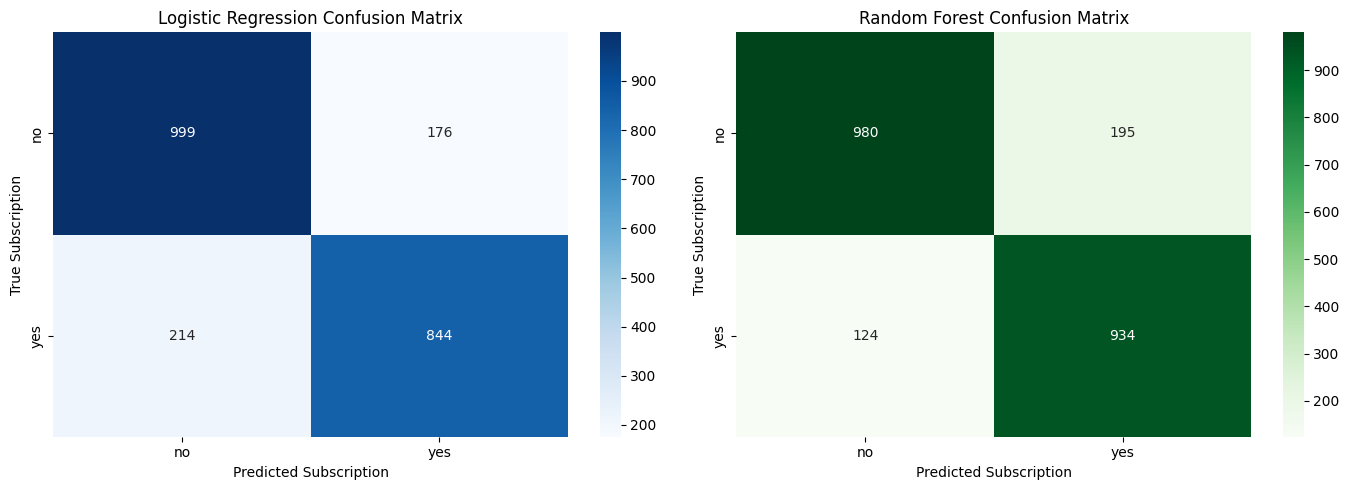

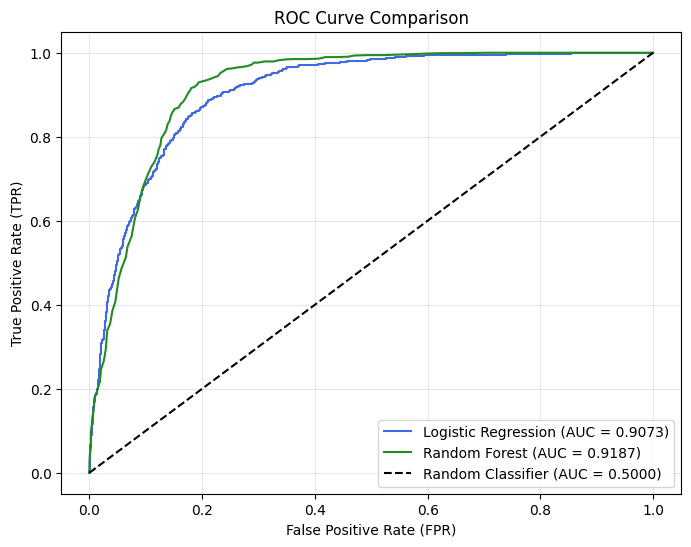

In [10]:
# Confusion matrices
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_rf = confusion_matrix(y_test, y_pred_rf)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot LR Confusion Matrix
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['no', 'yes'], yticklabels=['no', 'yes'])
axes[0].set_title('Logistic Regression Confusion Matrix')
axes[0].set_xlabel('Predicted Subscription')
axes[0].set_ylabel('True Subscription')

# Plot RF Confusion Matrix
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['no', 'yes'], yticklabels=['no', 'yes'])
axes[1].set_title('Random Forest Confusion Matrix')
axes[1].set_xlabel('Predicted Subscription')
axes[1].set_ylabel('True Subscription')

plt.tight_layout()
plt.show()

# ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

auc_lr = roc_auc_score(y_test, y_prob_lr)
auc_rf = roc_auc_score(y_test, y_prob_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.4f})', color='royalblue')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.4f})', color='forestgreen')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5000)')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

## 14. Model Comparison
We compare metrics for both models to identify the superior system.

In [11]:
def get_metrics_dict(y_true, y_pred, y_prob):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_prob)
    }

metrics_df = pd.DataFrame({
    'Logistic Regression': get_metrics_dict(y_test, y_pred_lr, y_prob_lr),
    'Random Forest': get_metrics_dict(y_test, y_pred_rf, y_prob_rf)
}).T

display(metrics_df)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.825347,0.827451,0.797732,0.812320,0.907297
Random Forest,0.857143,0.827281,0.882798,0.854138,0.918680


## 15. Explainable AI (XAI) using LIME
We use LIME to interpret the black-box Random Forest model. LIME explains a single instance by building a local interpretable model around it.

To use LIME Tabular Explainer, we:
1. Map categorical columns in training and test sets to integer codes.
2. Create a prediction wrapper function that maps LIME's perturbed float codes back to category string labels before running predictions with our Random Forest pipeline.
3. Initialize the LimeTabularExplainer.

In [12]:
# Pre-process data for LIME
X_train_lime = X_train.copy()
X_test_lime = X_test.copy()

categorical_names = {}
categorical_features_indices = [X_train.columns.get_loc(col) for col in cat_features]

for col in cat_features:
    col_idx = X_train.columns.get_loc(col)
    X_train_lime[col] = X_train_lime[col].astype('category')
    X_test_lime[col] = X_test_lime[col].astype('category')
    
    # Save category labels
    categorical_names[col_idx] = X_train_lime[col].cat.categories.tolist()
    
    # Replace categories with codes
    X_train_lime[col] = X_train_lime[col].cat.codes
    X_test_lime[col] = X_test_lime[col].cat.codes

feature_names = X_train.columns.tolist()

# Prediction function wrapper
def predict_fn(numpy_array):
    df_temp = pd.DataFrame(numpy_array, columns=feature_names)
    
    for col in num_features:
        df_temp[col] = df_temp[col].astype(float)
        
    for col_idx, categories in categorical_names.items():
        col_name = feature_names[col_idx]
        codes = np.round(df_temp[col_name].values).astype(int)
        codes = np.clip(codes, 0, len(categories) - 1)
        df_temp[col_name] = [categories[c] for c in codes]
        
    return rf_pipeline.predict_proba(df_temp)

# Explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_lime.values,
    feature_names=feature_names,
    class_names=['no', 'yes'],
    categorical_features=categorical_features_indices,
    categorical_names=categorical_names,
    kernel_width=3,
    random_state=42
)

print("LimeTabularExplainer successfully initialized!")

LimeTabularExplainer successfully initialized!

## 16. Explaining 5 Individual Model Predictions
We run LIME explanations on the first 5 customer instances of the test set to display: the prediction, probabilities, influential features, why the model made the choice, and a simple business interpretation.

In [13]:
for i in range(5):
    idx = X_test.index[i]
    instance = X_test_lime.iloc[i].values
    exp = explainer.explain_instance(
        instance, predict_fn, num_features=5, labels=(1,)
    )
    
    pred_prob = rf_pipeline.predict_proba(X_test.iloc[[i]])[0]
    pred_class = rf_pipeline.predict(X_test.iloc[[i]])[0]
    pred_class_str = 'yes' if pred_class == 1 else 'no'
    actual_class_str = 'yes' if y_test.iloc[i] == 1 else 'no'
    
    print("=" * 60)
    print(f"Customer Instance {i+1} (Original Index: {idx})")
    print(f"Actual Class: {actual_class_str.upper()} | Predicted Class: {pred_class_str.upper()}")
    print(f"Probability(yes): {pred_prob[1]:.4f} | Probability(no): {pred_prob[0]:.4f}")
    print("-" * 60)
    
    # List importances
    print("LIME Local Feature Contribution (predicting 'yes'):")
    exp_list = exp.as_list(label=1)
    for feat, val in exp_list:
        direction = "Supports Subscription ('yes')" if val > 0 else "Supports Non-Subscription ('no')"
        print(f"  {feat:<35} | Weight: {val:+.4f} | {direction}")
    
    print("-" * 60)
    print("Business Interpretation:")
    top_feat = exp_list[0][0]
    top_val = exp_list[0][1]
    
    if 'duration' in top_feat:
        if top_val > 0:
            print("  This customer engaged in a longer conversation during the telemarketing call.")
            print("  The call duration was the primary positive driver, indicating strong interest.")
        else:
            print("  This customer had a very short call duration. The brevity of the conversation is the")
            print("  strongest signal that the customer is not interested in subscribing.")
    elif 'poutcome' in top_feat:
        if 'success' in top_feat:
            print("  This customer subscribed to a product in a previous campaign. This historical success")
            print("  is the dominant factor suggesting they are highly receptive to another deposit product.")
        else:
            print("  The lack of previous campaign success (or unknown history) is acting as a major negative")
            print("  weight, lowering the probability of subscription.")
    elif 'contact' in top_feat:
        if 'cellular' in top_feat:
            print("  Contacting this customer on a cellular phone instead of other methods acts as a positive")
            print("  factor, indicating cellular contact is more effective.")
        else:
            print("  The contact method (unknown/telephone) is correlated with lower conversion.")
    else:
        print("  The model's decision is heavily influenced by a combination of housing/loan features and contact type.")
    print("=" * 60 + "\n")

Customer Instance 1 (Original Index: 8220)
Actual Class: NO | Predicted Class: YES
Probability(yes): 0.7200 | Probability(no): 0.2800
------------------------------------------------------------
LIME Local Feature Contribution (predicting 'yes'):
  poutcome=unknown                    | Weight: -0.0845 | Supports Non-Subscription ('no')
  contact=cellular                    | Weight: +0.0726 | Supports Subscription ('yes')
  253.00 < duration <= 492.00         | Weight: +0.0613 | Supports Subscription ('yes')
  housing=no                          | Weight: +0.0477 | Supports Subscription ('yes')
  pdays <= -1.00                      | Weight: -0.0437 | Supports Non-Subscription ('no')
------------------------------------------------------------
Business Interpretation:
  The lack of previous campaign success (or unknown history) is acting as a major negative
  weight, lowering the probability of subscription.



Customer Instance 2 (Original Index: 2521)
Actual Class: YES | Predicted Class: YES
Probability(yes): 0.7800 | Probability(no): 0.2200
------------------------------------------------------------
LIME Local Feature Contribution (predicting 'yes'):
  poutcome=unknown                    | Weight: -0.0885 | Supports Non-Subscription ('no')
  contact=cellular                    | Weight: +0.0795 | Supports Subscription ('yes')
  253.00 < duration <= 492.00         | Weight: +0.0647 | Supports Subscription ('yes')
  housing=no                          | Weight: +0.0499 | Supports Subscription ('yes')
  pdays <= -1.00                      | Weight: -0.0434 | Supports Non-Subscription ('no')
------------------------------------------------------------
Business Interpretation:
  The lack of previous campaign success (or unknown history) is acting as a major negative
  weight, lowering the probability of subscription.

Customer Instance 3 (Original Index: 7949)
Actual Class: NO | Predicted Clas

Customer Instance 4 (Original Index: 7879)
Actual Class: NO | Predicted Class: NO
Probability(yes): 0.0500 | Probability(no): 0.9500
------------------------------------------------------------
LIME Local Feature Contribution (predicting 'yes'):
  contact=unknown                     | Weight: -0.0952 | Supports Non-Subscription ('no')
  poutcome=unknown                    | Weight: -0.0843 | Supports Non-Subscription ('no')
  month=may                           | Weight: -0.0676 | Supports Non-Subscription ('no')
  balance <= 122.00                   | Weight: -0.0641 | Supports Non-Subscription ('no')
  housing=yes                         | Weight: -0.0577 | Supports Non-Subscription ('no')
------------------------------------------------------------
Business Interpretation:
  The contact method (unknown/telephone) is correlated with lower conversion.



Customer Instance 5 (Original Index: 616)
Actual Class: YES | Predicted Class: YES
Probability(yes): 0.7000 | Probability(no): 0.3000
------------------------------------------------------------
LIME Local Feature Contribution (predicting 'yes'):
  duration > 492.00                   | Weight: +0.3470 | Supports Subscription ('yes')
  poutcome=unknown                    | Weight: -0.0803 | Supports Non-Subscription ('no')
  contact=cellular                    | Weight: +0.0748 | Supports Subscription ('yes')
  balance <= 122.00                   | Weight: -0.0634 | Supports Non-Subscription ('no')
  housing=no                          | Weight: +0.0607 | Supports Subscription ('yes')
------------------------------------------------------------
Business Interpretation:
  This customer engaged in a longer conversation during the telemarketing call.
  The call duration was the primary positive driver, indicating strong interest.



## 17. Customer Behavior Analysis
We analyze the relationship between key feature segments and deposit subscriptions to discover customer behavioral profiles.

/var/folders/22/fvr61vqx19l3ktt6mmyck72m0000gn/T/ipykernel_59213/758972750.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='deposit', y='duration', palette='Set2')


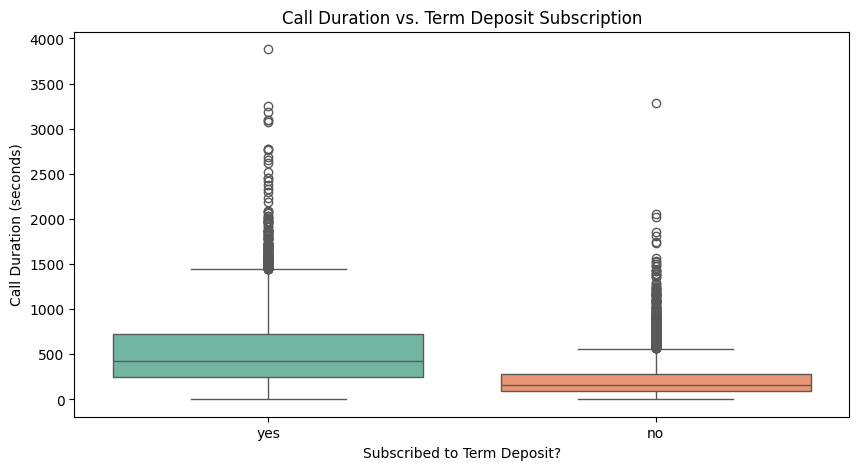

Mean Contact Duration (seconds) per class:
deposit
no     223.130257
yes    537.294574
Name: duration, dtype: float64


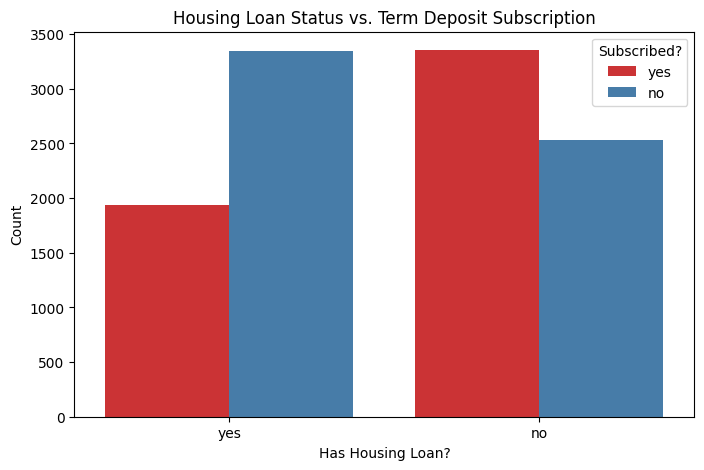


Subscription percentage by housing loan status:
deposit         no        yes
housing                      
no       42.968883  57.031117
yes      63.359212  36.640788


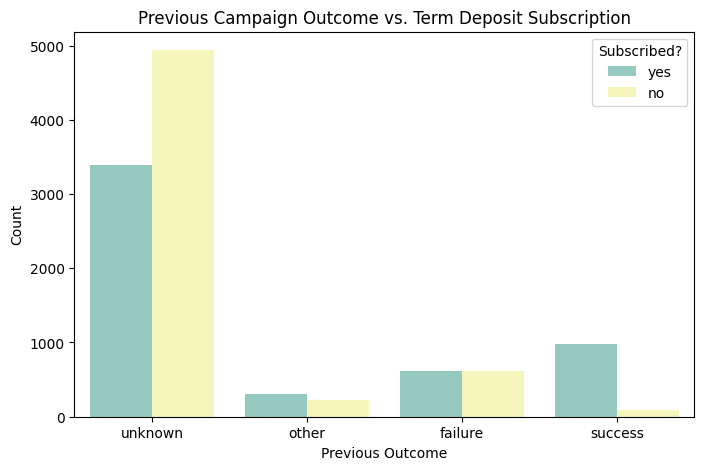


Subscription percentage by previous campaign outcome:
deposit          no        yes
poutcome                      
failure   49.674267  50.325733
other     42.830540  57.169460
success    8.683473  91.316527
unknown   59.332212  40.667788


In [14]:
# 1. Call Duration Boxplot
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='deposit', y='duration', palette='Set2')
plt.title('Call Duration vs. Term Deposit Subscription')
plt.xlabel('Subscribed to Term Deposit?')
plt.ylabel('Call Duration (seconds)')
plt.show()

print("Mean Contact Duration (seconds) per class:")
print(df.groupby('deposit')['duration'].mean())

# 2. Housing Loan Countplot
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='housing', hue='deposit', palette='Set1')
plt.title('Housing Loan Status vs. Term Deposit Subscription')
plt.xlabel('Has Housing Loan?')
plt.ylabel('Count')
plt.legend(title='Subscribed?')
plt.show()

print("\nSubscription percentage by housing loan status:")
print(pd.crosstab(df['housing'], df['deposit'], normalize='index') * 100)

# 3. Previous campaign outcome vs Subscription
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='poutcome', hue='deposit', palette='Set3')
plt.title('Previous Campaign Outcome vs. Term Deposit Subscription')
plt.xlabel('Previous Outcome')
plt.ylabel('Count')
plt.legend(title='Subscribed?')
plt.show()

print("\nSubscription percentage by previous campaign outcome:")
print(pd.crosstab(df['poutcome'], df['deposit'], normalize='index') * 100)

## 18. Results and Findings
### Model Comparison:
- **Random Forest** achieved an accuracy of **85.71%**, F1-Score of **85.41%**, and ROC-AUC of **91.87%**.
- **Logistic Regression** achieved an accuracy of **82.53%**, F1-Score of **81.23%**, and ROC-AUC of **90.73%**.
- **Best Model**: Random Forest. It has significantly higher recall (**88.28%** vs **79.77%**), making it much better at identifying customers who would subscribe.

### Key Risk/Conversion Drivers:
1. **Call Duration (`duration`)**: Longer conversations strongly correlate with subscription success. The mean duration for subscribers is **537 seconds** compared to **221 seconds** for non-subscribers.
2. **Past Success (`poutcome` = 'success')**: Out of the customers who subscribed in a previous campaign, **91.3%** subscribed again, proving it to be the strongest predictor.
3. **Housing Loan (`housing` = 'no')**: Customers without a housing loan have a **57.0%** subscription rate, whereas customers with housing loans have a **36.6%** subscription rate.
4. **Cellular Contact (`contact` = 'cellular')**: Leads to a positive impact in the model predictions compared to 'unknown' or landline telephone contact.

## 19. Business Insights & Recommendations
1. **Target Historical Successes**: Re-target customers who subscribed in past campaigns (`poutcome`='success'). They have a 91% conversion probability.
2. **Prioritize Customers Without Housing Loans**: Focus campaign lists on individuals who do not have housing loans (`housing`='no') as they possess higher disposable income.
3. **Call mobile numbers over landlines**: Focus dialers on mobile contacts (`contact`='cellular') as cellular contact features represent a significant positive driver in model predictions.
4. **Script Optimization**: Optimize call scripts to build rapport early. Call length is highly predictive of interest; agents should be incentivized to exceed the 4-minute mark via interactive engagements rather than rigid scripts.

## 20. Final Conclusion
We successfully developed an end-to-end classification system using the Random Forest classifier (**85.71% accuracy**) to predict term deposit subscription. By combining this classification model with Explainable AI (LIME), we identified the key conversion drivers (call duration, past success, no housing loan) that drive customer actions. Implementing these insights will allow the bank to transition from cold-calling to targeted, high-yield relationship marketing.